Correct convective power for viscous and inertial contributions
=====
***

In [2]:
using Plots
using Distributions
using StatsBase
using DelimitedFiles

Read total convective power

In [4]:
data = readdlm("power.dat")
tp = data[:,1].-data[1,1];
p = data[:,2];
vd = data[:,3];
od = data[:,4];

# remove redundant elements
deleteat!(tp,88105:88453)
deleteat!(p,88105:88453)
deleteat!(vd,88105:88453)
deleteat!(od,88105:88453)

ndata = length(tp)

152710

In [5]:
println("power p = ",mean(p),'\n',
    "viscous = ", mean(vd),'\n', 
    "ohmic =  ", mean(od))

power p = 3.257962807839238e12
viscous = 3.0194934125683323e10
ohmic =  2.392408543420601e12


Read magnetic energy

In [7]:
data = readdlm("e_mag.dat")
tm = (data[:,1].-data[1,1]);
me = data[:,2];

# remove redundant elements
deleteat!(tm,88105:88453);
deleteat!(me,88105:88453);

ndata = length(me)

152710

Compute magnetic decay time $\tau_m$

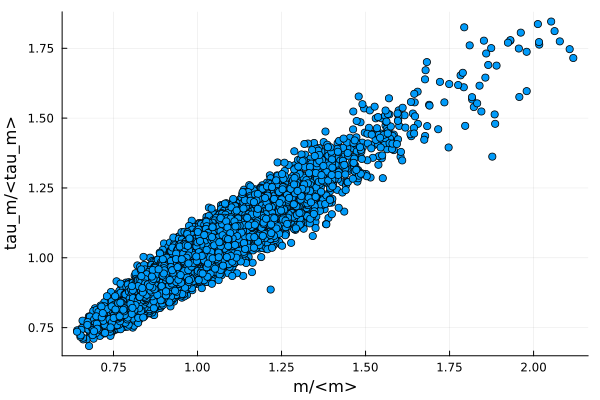

In [9]:
τ_m = 2*me./od

plot(me[1:10:end]/mean(me[1:10:end]),
    τ_m[1:10:end]/mean(τ_m[1:10:end]),
    st=:scatter,xlabel="m/<m>",
    ylabel="tau_m/<tau_m>",
    legend=nothing)

In [10]:
data = readdlm("e_kin.dat")
tv = data[:,1].-data[1,1];
ke = data[:,2];

# remove redundant elements
deleteat!(tv,88105:88453)
deleteat!(ke,88105:88453)

ndata = length(tv)

152710

Evaluate time derivatives

In [12]:
ndata = length(tv)
dke = zeros(ndata)
dme = zeros(ndata)

for i = 2 : ndata
    dke[i] = (ke[i]-ke[i-1])/(tv[i] - tv[i-1]) 
    dme[i] = (me[i]-me[i-1])/(tm[i]-tm[i-1]) 
end

dke[1] = dke[2]
dme[1] = dme[2]

6.719729854988892e11

In [13]:
println("Ratio of derivatives = ",std(dke)/ std(dme),'\n', 
        "Ratio of energies = ", mean(ke)/mean(me))

Ratio of derivatives = 0.26172848418531247
Ratio of energies = 0.08122240925053117


Correct the convective power

In [15]:
save_file = true
      
if save_file
    open("power_corrected.txt","w")  do io
        writedlm(io,[tp p-vd-dke])
    end
end
